In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(miloR))
suppressPackageStartupMessages(library(patchwork))

######################
## Define arguments ##
######################

p <- ArgumentParser(description='')
p$add_argument('--sce',             type="character",                               help='SingleCellExperiment file')
p$add_argument('--metadata',        type="character",                               help='Cell metadata file')
p$add_argument('--atlas_metadata',  type="character",                               help='Atlas metadata file')
p$add_argument('--stage',           type="character",                               help='Stages to include')
p$add_argument('--features',        type="integer",    default=2500,                help='Number of features')
p$add_argument('--npcs',            type="integer",    default=50,                  help='Number of PCs')
p$add_argument('--n_neighbors',     type="integer",    default=30,     help='Number of neighbours')
p$add_argument('--tdTom_corr', action="character",                                 help='Keep tdTom+ cells in WT samples (otherwise removed)')
p$add_argument('--prop',        type="double",     default=0.3,     help='Proportion of cells to sample for MILO')
#p$add_argument('--remove_ExE_cells', action="store_true",                                 help='Remove ExE cells?')
p$add_argument('--outdir',          type="character",                               help='Output file')

args <- p$parse_args(commandArgs(TRUE))

ERROR: Error in .stop(output, "parse error:"): parse error:
usage: PROGRAM [-h] [--sce SCE] [--metadata METADATA]
               [--atlas_metadata ATLAS_METADATA] [--stage STAGE]
               [--features FEATURES] [--npcs NPCS] [--n_neighbors N_NEIGHBORS]
               [--tdTom_corr] [--prop PROP] [--outdir OUTDIR]
PROGRAM: error: unrecognized arguments: /home/bt392/.local/share/jupyter/runtime/kernel-f41712d2-127d-42d6-8f4c-ca04c02ac814.json


In [97]:
#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))
test = TRUE

if(test){
## START TEST ##
    args = list()
args$sce <- io$rna.sce
args$metadata <- io$metadata
args$stage <- c('E7.5_E8.5')#, 'E8.5', 'E9.5')
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/sample_metadata.txt.gz"
args$features <- 2500
args$npcs <- 50 
args$n_neighbors = 45 
args$prop = 0.15 # put at 0.15 - 0.2
args$remove_ExE_cells <- FALSE
args$tdTom_corr = "FALSE"
args$outdir <- paste0(io$basedir,"/results/rna/MiloR/test")
## END TEST ##
}

# If passing multiple timepoints split in vector
args$stage = strsplit(args$stage, "_")[[1]] 

dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [98]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & stage %in% args$stage] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]


if(args$tdTom_corr!='TRUE'){
    sample_metadata = sample_metadata[tdTom==tdTom_corr]
}

if(test){
    sample_metadata = sample_metadata[sample(1:nrow(sample_metadata), nrow(sample_metadata)/10)]
}

In [75]:
###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [76]:
###############
## Get PCA   ##
###############

# Get Reduced Dims
# PCA
if(length(args$stage)>1){
    message('loading precomputed PCA')
    pca_file = sprintf("%s/results/rna/dimensionality_reduction/sce/pca_features%d_pcs%d.txt.gz", io$basedir, args$features, args$npcs)
    pca = fread(pca_file)[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
} else {
    message('runnning PCA')
    library(batchelor)
    # Run PCA for sample
    decomp <- modelGeneVar(sce, block=colData(sce)$sample)
    decomp <- decomp[decomp$mean > 0.01,]
    hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames
    sce_filt <- sce[hvgs,]
    
    meta = colData(sce_filt)
    #get order: oldest to youngest; most cells to least cells
    order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
    order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
    order_df$stage = factor(order_df$stage, 
                            levels = rev(c(
                                        "E9.5",
                                        "E8.5", 
                                        "E7.5"
                                          )))
    order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
    order_df$stage = as.character(order_df$stage)

    pca = doBatchCorrect(counts = logcounts(sce_filt), 
                                 timepoints = meta$stage, 
                                 samples = meta$sample, 
                                 timepoint_order = order_df$stage, 
                                 sample_order = order_df$sample, 
                                 npc = args$npcs)
                         
   colnames(pca) <- paste0("PC",1:ncol(pca))
}

loading precomputed PCA



In [77]:
# Umap -> doesn't currently give option to chose NN & dist of final umap
umap_file = sprintf("%s/results/rna/dimensionality_reduction/sce/umap_features%d_pcs%d_neigh30_dist0.5.txt.gz", io$basedir, args$features, args$npcs)
umap = fread(umap_file)[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
# Atlas umap
umap_atlas = fread(args$atlas_metadata)[,c('cell', 'umapX', 'umapY')]
umap_mapped = data.table(actual_cell = colnames(sce), cell = colData(sce)$closest.cell_mnn) %>% 
    .[,idx:=1:nrow(.)] %>%
    merge(umap_atlas, by='cell') %>% 
    .[order(idx), c('actual_cell', 'umapX', 'umapY')] %>% 
    .[match(colnames(sce), actual_cell)] %>% 
    tibble::column_to_rownames("actual_cell") %>% as.matrix


In [78]:
# Add Reduced Dims to SCE object
reducedDims(sce) <- list(pca=pca, 
                         umap=umap,
                         umap_atlas = umap_mapped)

In [79]:
########################
## Create MILO object ##
########################

# create object
Milo_sce <- Milo(sce)

colData(Milo_sce)$sample_ko = paste0(colData(Milo_sce)$sample, '_',  colData(Milo_sce)$tdTom_corr)

# Build graph
Milo_sce <- buildGraph(Milo_sce, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       reduced.dim = "pca")

# Identify neighbourhoods from NN-cells
# lower prop for larger datasets
Milo_sce <- makeNhoods(Milo_sce, 
                       prop = args$prop, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       refined = TRUE, 
                       reduced_dims = "pca")

Constructing kNN graph with k:45

Checking valid object



In [91]:
# count cells of different samples per neighbourhood
Milo_sce <- countCells(Milo_sce, meta.data = as.data.frame(colData(Milo_sce)), sample="sample_ko")

# Calculate Neighbourhood Distances (most time consuming step)
Milo_sce <- calcNhoodDistance(Milo_sce, d=args$npcs, reduced.dim = "pca")

# Build neighbourhood graph
Milo_sce <- buildNhoodGraph(Milo_sce)

# Save MILO object
outfile = sprintf("%s/results/rna/MiloR/%s_Milo_features%d_pcs%d_tdTomcorr%s.rds",io$basedir, paste(args$stage, collapse ='_'), args$features, args$npcs, args$tdTom_corr)
saveRDS(Milo_sce, outfile)

# Embryo design table
embryo_design <- data.frame(colData(Milo_sce))[,c("sample_ko", "sample", 'tdTom_corr', 'tdTom', 'stage', 'pool')]

embryo_design <- distinct(embryo_design)
embryo_design$stage = droplevels(factor(embryo_design$stage, levels = c('E7.5', 'E8.5', 'E9.5')))
rownames(embryo_design) <- embryo_design$sample_ko

# Test differential abundance per hood
# Correction per stage skipped because this info is present in the pool, which also corrects for differences between embryos of the same stage
da_results <- testNhoods(Milo_sce, design = ~ pool + tdTom_corr, design.df = embryo_design, reduced.dim="pca")


# Save MILO results
outfile = sprintf("%s/results/rna/MiloR/%s_Milo_features%d_pcs%d_tdTomcorr%s_DAresults.csv",io$basedir, paste(args$stage, collapse ='_'), args$features, args$npcs, args$tdTom_corr)
write.csv(da_results, outfile, row.names=FALSE)

Checking meta.data validity

Counting cells in neighbourhoods

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



In [101]:
##################
## Plot results ##
##################

p1 = ggplot(da_results, aes(PValue)) + 
    geom_histogram(bins=50) + 
    theme_bw()

p2 = ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
    geom_point() +
    geom_hline(yintercept = 1) + ## Mark significance threshold (10% FDR)
    theme_bw()


## Plot single-cell UMAP
p3 = plotReducedDim(Milo_sce, dimred = "umap_atlas", colour_by="tdTom_corr", text_by = "celltype.mapped_mnn", 
                          text_size = 3, point_size=0.3, text_colour = "grey30") +
    scale_color_manual(values=opts$tdTom.color, name = 'tdTom') + 
    theme_void() + 
    theme(legend.position='right') +
    guides(fill="none")

## Plot neighbourhood graph
p4 = plotNhoodGraphDA(Milo_sce, da_results, layout="umap_atlas",alpha=0.05) 

# plot stats + graphs
outfile = sprintf("%s/results/rna/MiloR/%s_Milo_features%d_pcs%d_tdTomcorr%s_plots.pdf",io$basedir, paste(args$stage, collapse ='_'), args$features, args$npcs, args$tdTom_corr)
pdf(outfile, width=14, height = 7)
    p1 + p2
    p3 + p4 +
      plot_layout(guides="collect")
dev.off()

# If significant results create beeswarm plot
if(TRUE %in% unique(da_results$SpatialFDR < 0.05)){
    # Find Neighbourhood groups
    da_results <- groupNhoods(Milo_sce, da_results, max.lfc.delta = 0.5, overlap = 20)

    # Annotate hoods by celltype
    da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype.mapped_mnn")

    # Annotate 'mixed' hoods when there is not one main celltype
    da_results$celltype.mapped_mnn <- ifelse(da_results$celltype.mapped_mnn_fraction < 0.55, "Mixed", da_results$celltype.mapped_mnn)

    # Save MILO object
    outfile = sprintf("%s/results/rna/MiloR/%s_Milo_features%d_pcs%d_tdTomcorr%s_DAresults.csv",io$basedir, paste(args$stage, collapse ='_'), args$features, args$npcs, args$tdTom_corr)
    write.csv(da_results, outfile, row.names=FALSE)
    
    # plot DA beeswarm
    p6 = plotDAbeeswarm(da_results, group.by = "celltype.mapped_mnn")

    # # save beeswarm
    outfile = sprintf("%s/results/rna/MiloR/%s_Milo_features%d_pcs%d_tdTomcorr%s_beeswarm.pdf",io$basedir, paste(args$stage, collapse ='_'), args$features, args$npcs, args$tdTom_corr)
    pdf(outfile, width=14, height = length(unique(da_results$celltype.mapped_mnn))/2.5)
        print(p6)
    dev.off()
}



Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


png 
  2

Found 1 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping

Converting celltype.mapped_mnn to factor...

Converting group.by to factor...



png 
  2

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


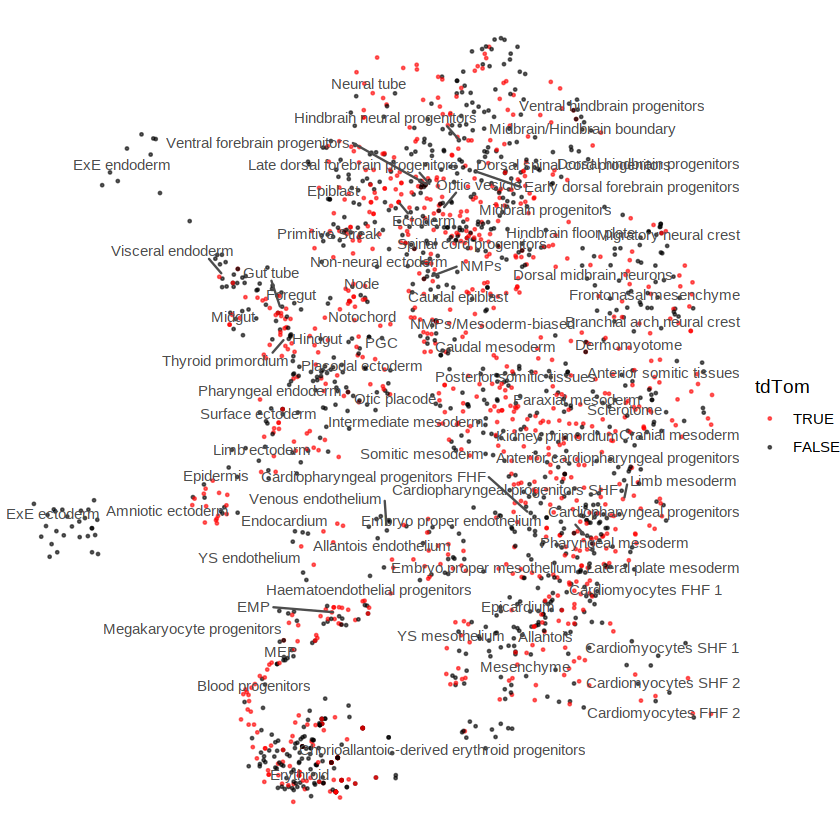

In [102]:
p3

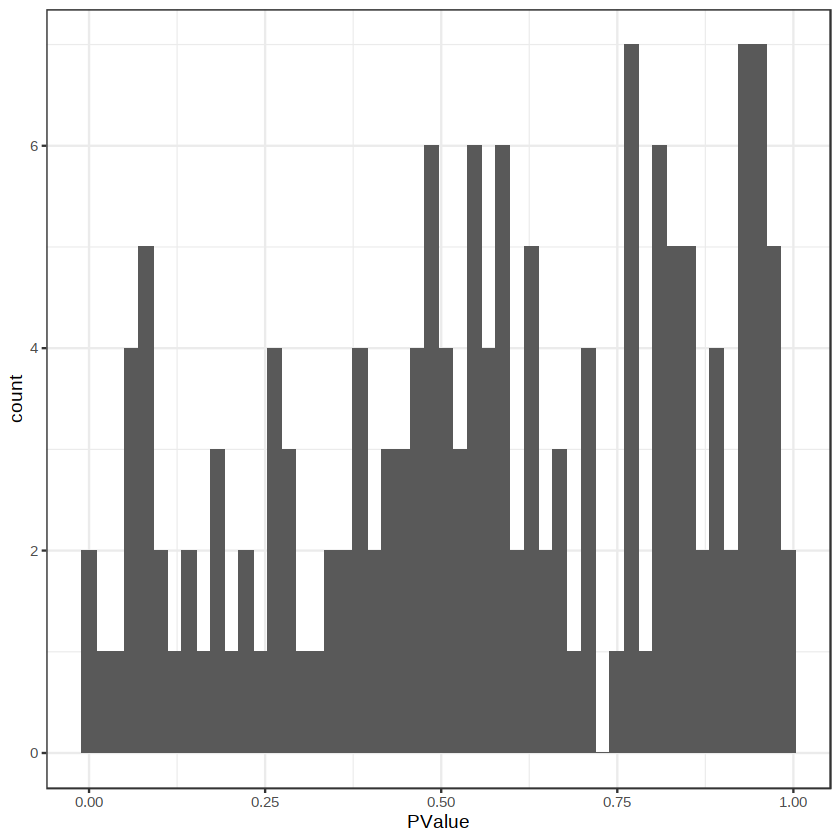

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


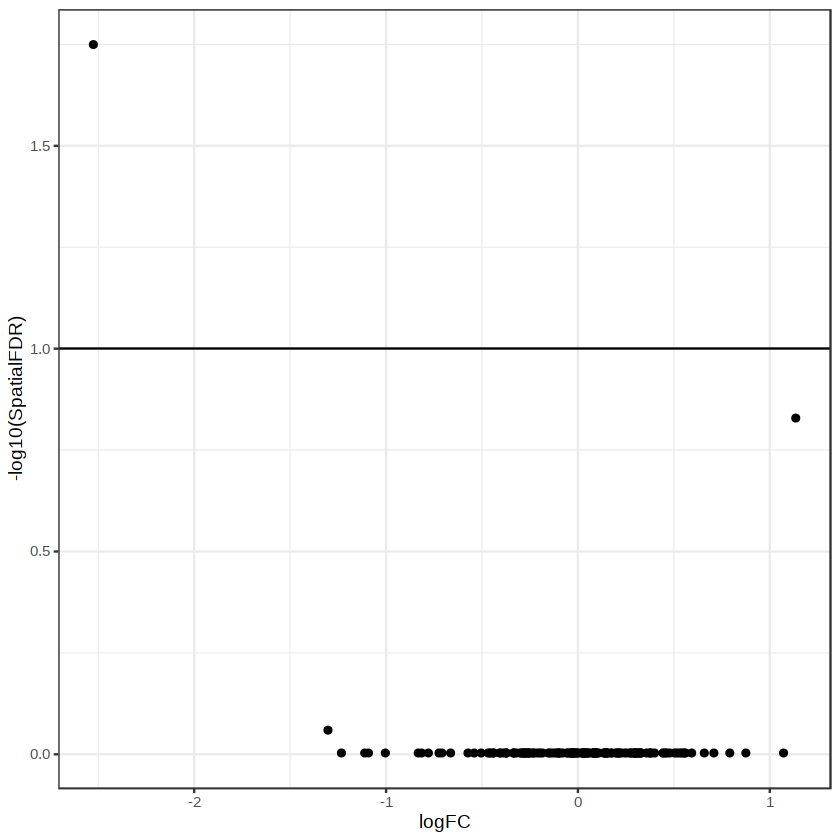

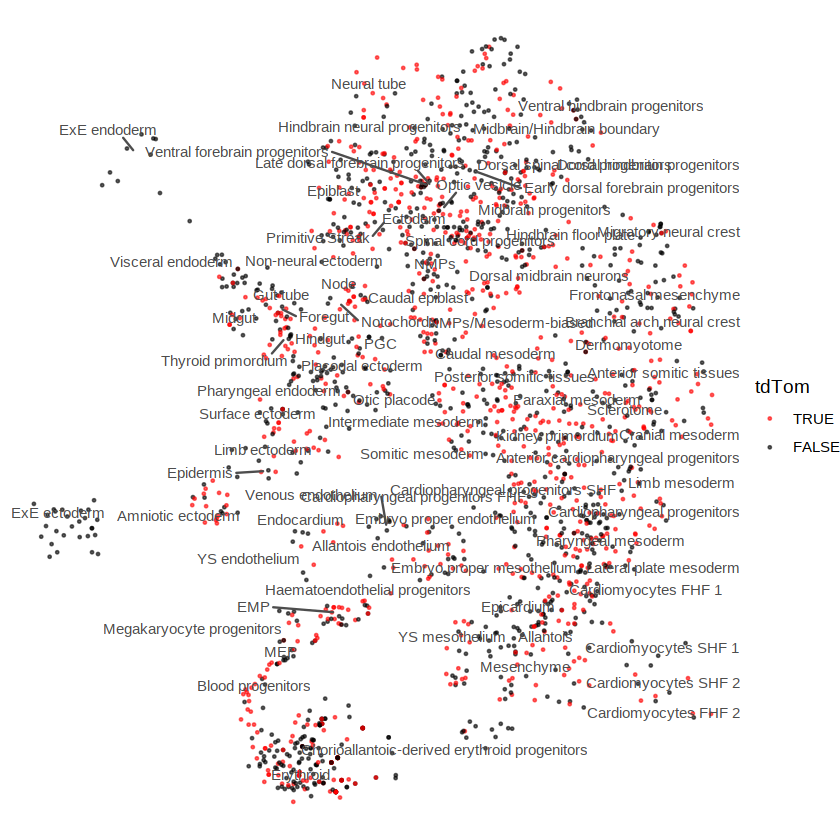

ERROR: Error in eval(expr, envir, enclos): object 'p5' not found


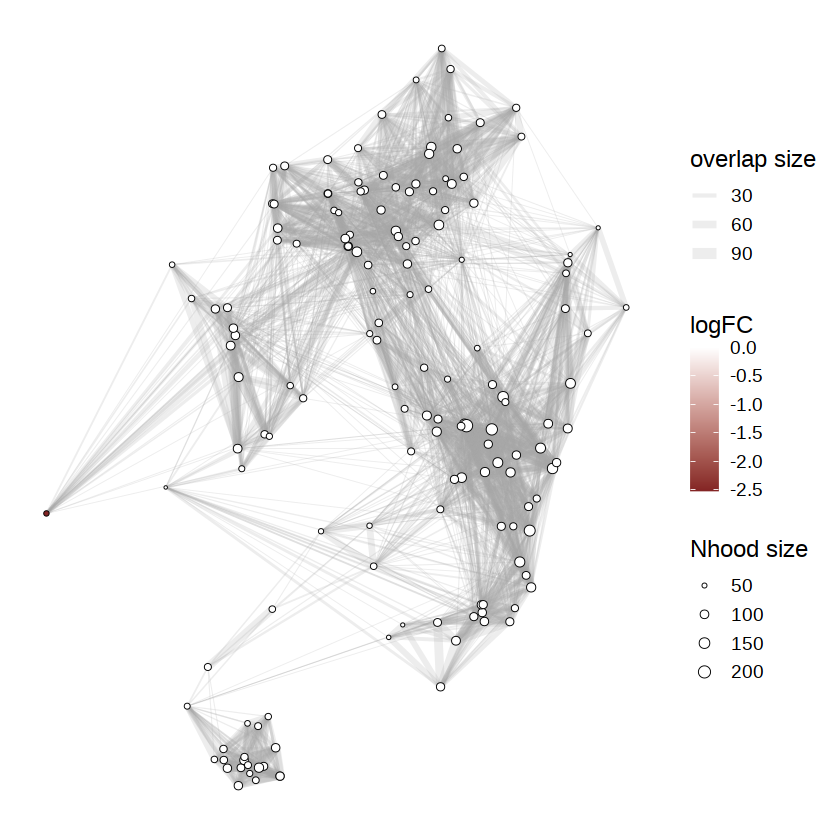

In [93]:
p1
p2
p3
p4
p6